In [4]:
!pip install xgboost


In [5]:
!pip install tensorflow


In [6]:
# 1) Importing Necessary Libraries and Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [7]:
# Load the dataset
df = pd.read_csv('bitcoin.csv')
print("---------- Dataset Loaded Successfully ----------")
print(df.head())


# 2)  Data Preprocessing 

# --- Date Conversion and Indexing ---
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


---------- Dataset Loaded Successfully ----------
         Date        Open        High         Low       Close   Adj Close  \
0  2014-09-17  465.864014  468.174011  452.421997  457.334015  457.334015   
1  2014-09-18  456.859985  456.859985  413.104004  424.440002  424.440002   
2  2014-09-19  424.102997  427.834991  384.532013  394.795990  394.795990   
3  2014-09-20  394.673004  423.295990  389.882996  408.903992  408.903992   
4  2014-09-21  408.084991  412.425995  393.181000  398.821014  398.821014   

     Volume  
0  21056800  
1  34483200  
2  37919700  
3  36863600  
4  26580100  


In [8]:
# Feature Engineering 
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Upper'] = df['BB_Middle'] + 2 * df['Close'].rolling(window=20).std()
df['BB_Lower'] = df['BB_Middle'] - 2 * df['Close'].rolling(window=20).std()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)
print("\n---------- Feature Engineering Complete ----------")
print(df.head())


---------- Feature Engineering Complete ----------
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-10-06  320.389008  345.134003  302.559998  330.079010  330.079010   
2014-10-07  330.584015  339.247009  320.481995  336.187012  336.187012   
2014-10-08  336.115997  354.364014  327.187988  352.940002  352.940002   
2014-10-09  352.747986  382.726013  347.687012  365.026001  365.026001   
2014-10-10  364.687012  375.066986  352.963013  361.562012  361.562012   

              Volume      SMA_20      EMA_20   BB_Middle    BB_Upper  \
Date                                                                   
2014-10-06  79011800  389.910399  383.883180  389.910399  461.027732   
2014-10-07  49199900  383.853049  379.340688  383.853049  451.334641   
2014-10-08  54736300  380.278049  376.826337  380.278049  446.265429   
2014-10-09  83641104  378.789549  375.702495  378.789549  444.741094 

In [9]:
# Data Splitting and Normalization
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'EMA_20', 'BB_Upper', 'BB_Lower', 'RSI']
X = df[features]
y = df['Target']

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("\n---------- Data Preprocessing Complete ----------")



Training set size: 2154
Testing set size: 539

---------- Data Preprocessing Complete ----------


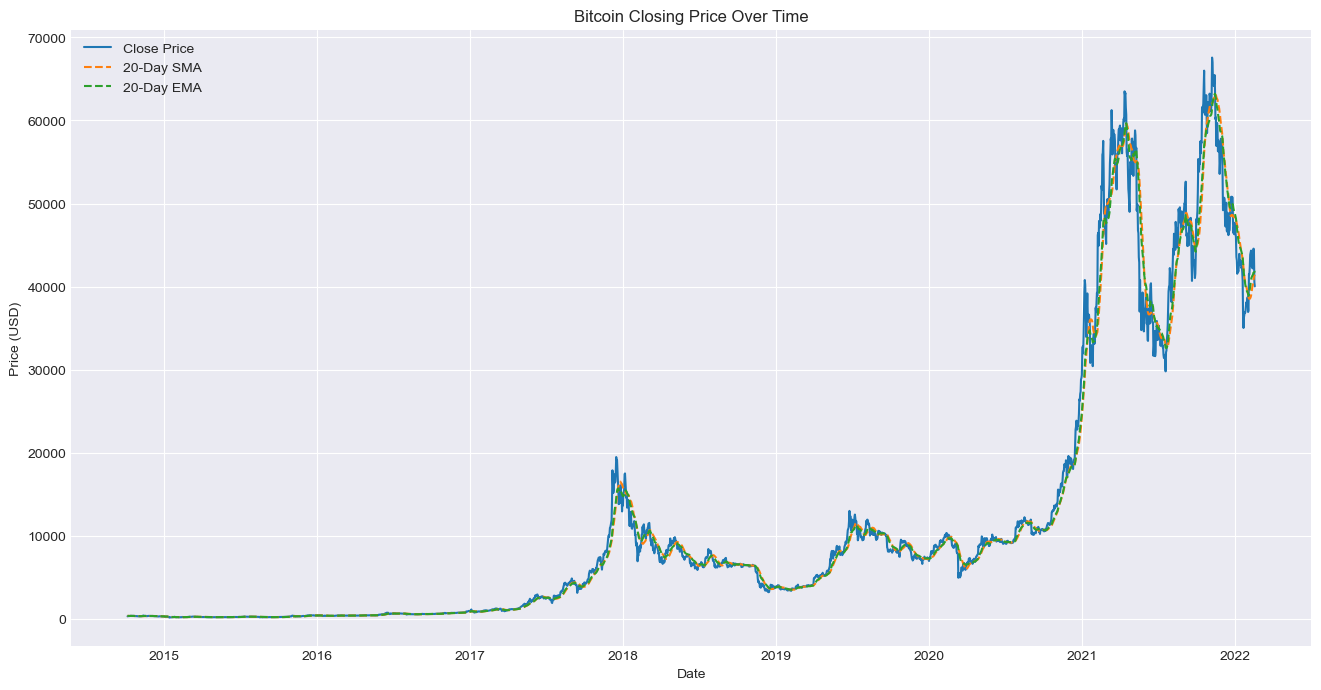

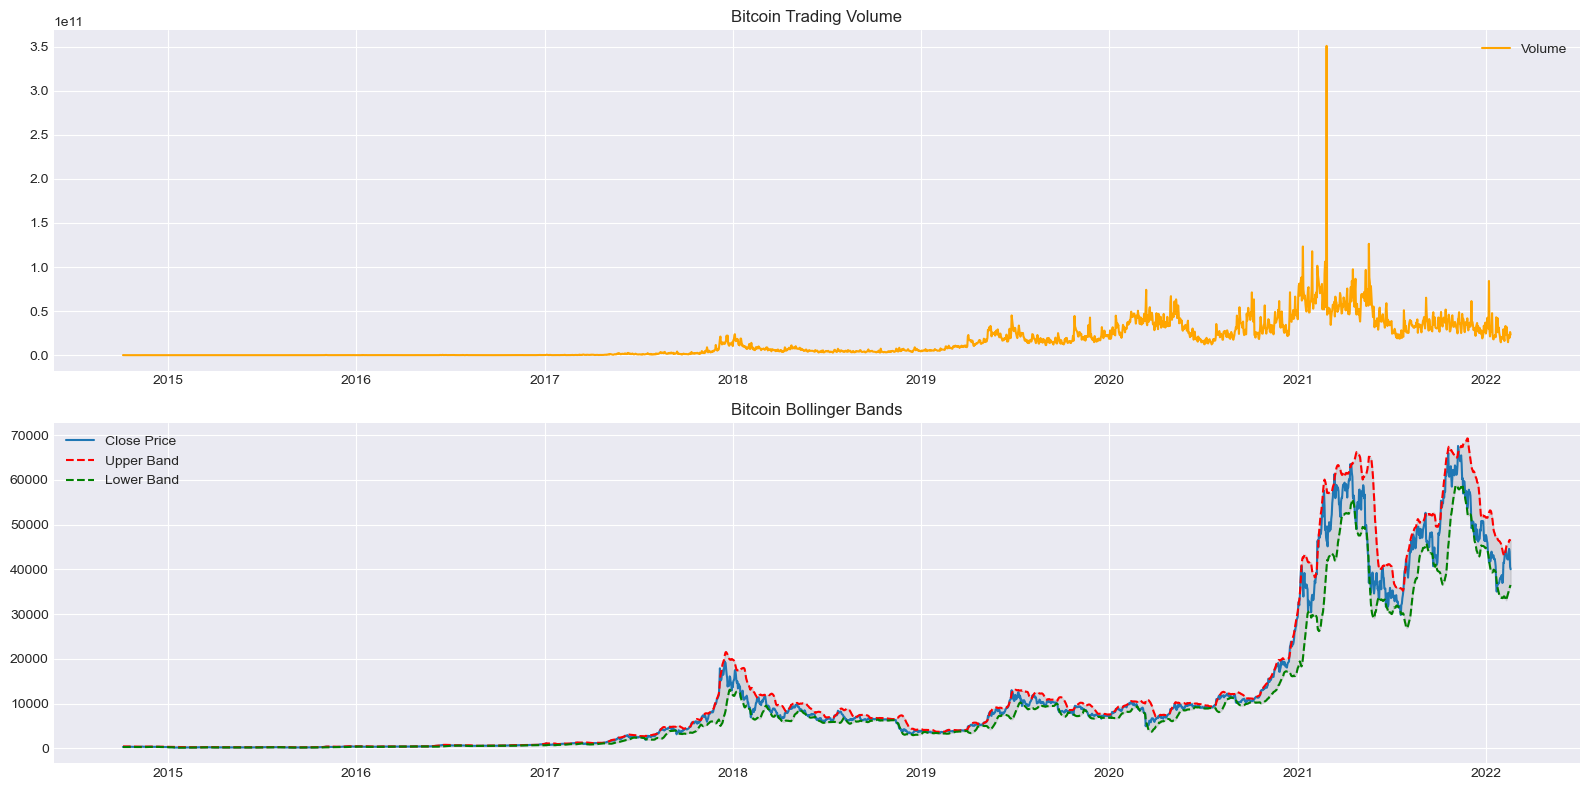

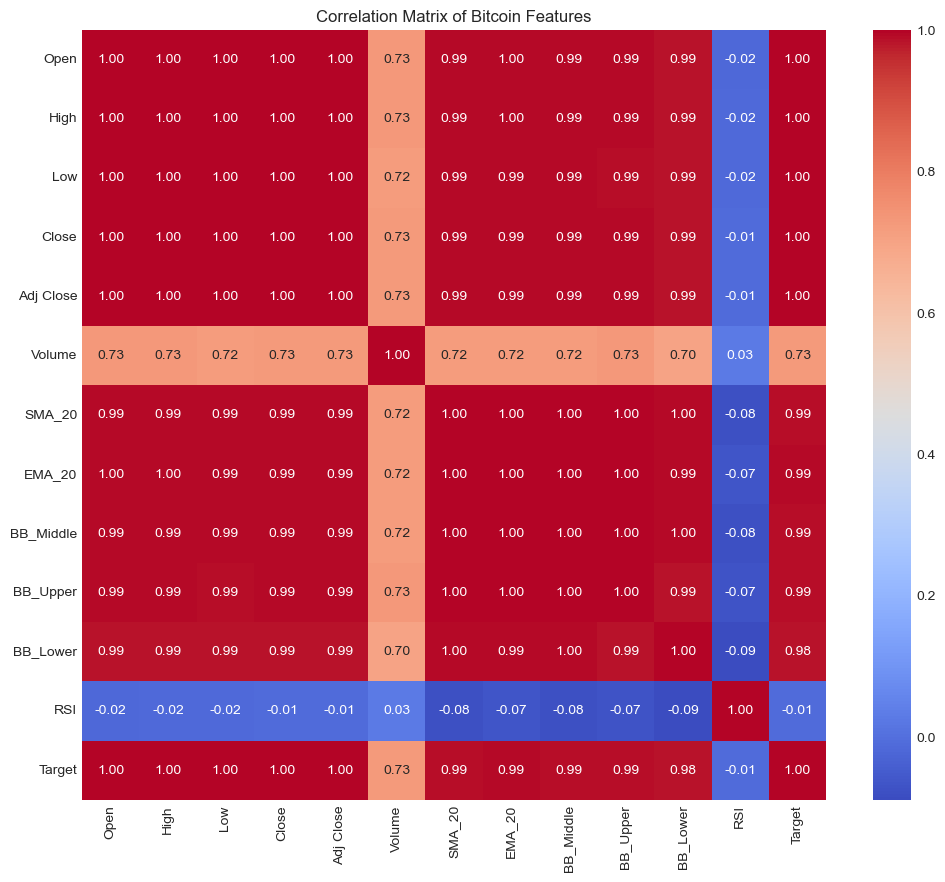

In [10]:
##  3)n Exploratory Data Analysis (EDA)
# Visualize Bitcoin Price Trends
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(16, 8))
plt.title('Bitcoin Closing Price Over Time')
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='20-Day SMA', linestyle='--')
plt.plot(df['EMA_20'], label='20-Day EMA', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Visualize Volume and Volatility
plt.figure(figsize=(16, 8))
plt.subplot(2, 1, 1)
plt.title('Bitcoin Trading Volume')
plt.plot(df['Volume'], label='Volume', color='orange')
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Bitcoin Bollinger Bands')
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_Upper'], label='Upper Band', linestyle='--', color='red')
plt.plot(df['BB_Lower'], label='Lower Band', linestyle='--', color='green')
plt.fill_between(df.index, df['BB_Upper'], df['BB_Lower'], color='gray', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# Identify Correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Bitcoin Features')
plt.show()


Training Linear Regression...
Linear Regression RMSE: 1637.60119906607

Training Random Forest...
Random Forest RMSE: 27664.29003974696

Training Support Vector Regressor...
SVR RMSE: 35750.94129785815

Training XGBoost Regressor...
XGBoost RMSE: 28742.96257364959


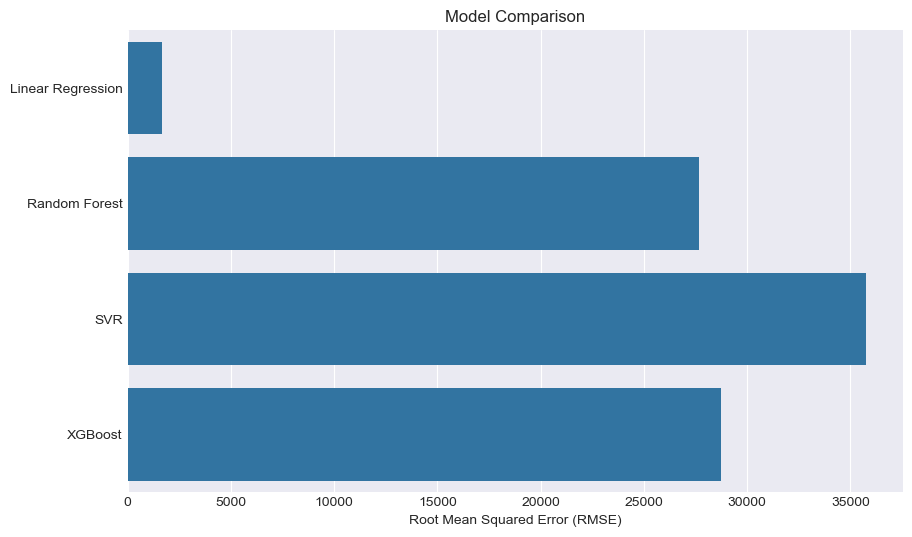


Training LSTM model...


C:\Users\vamsh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          12,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,701 (131.64 KB)

 Trainable params: 33,701 (131.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 37040656.0000 - val_loss: 2017195776.0000
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 36869656.0000 - val_loss: 2015343872.0000
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 36662384.0000 - val_loss: 2013134976.0000
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 36411784.0000 - val_loss: 2010433280.0000
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 36107432.0000 - val_loss: 2007217024.0000
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 35752204.0000 - val_loss: 2003431168.0000
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 35343464.0000 - val_loss: 1999126784.0000
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 34887800.0000 - val_loss: 1994241408.0000
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 34382736.0000 - val_loss: 1988894464.0000
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 33839012.0000 - val_loss: 1982

In [11]:

## 4) Model Training and Selection
# Dictionary to store model performance
models = {}

#  Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)
models['Linear Regression'] = np.sqrt(mean_squared_error(y_test, preds_lr))
print("Linear Regression RMSE:", models['Linear Regression'])

#  2. Random Forest
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
preds_rf = rf.predict(X_test_scaled)
models['Random Forest'] = np.sqrt(mean_squared_error(y_test, preds_rf))
print("Random Forest RMSE:", models['Random Forest'])

# 3. Support Vector Machine (SVM)
print("\nTraining Support Vector Regressor...")
svr = SVR(kernel='rbf', C=1000, gamma=0.1)
svr.fit(X_train_scaled, y_train)
preds_svr = svr.predict(X_test_scaled)
models['SVR'] = np.sqrt(mean_squared_error(y_test, preds_svr))
print("SVR RMSE:", models['SVR'])

#  4. XGBoost 
print("\nTraining XGBoost Regressor...")
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=1000, random_state=42)
xgb.fit(X_train_scaled, y_train)
preds_xgb = xgb.predict(X_test_scaled)
models['XGBoost'] = np.sqrt(mean_squared_error(y_test, preds_xgb))
print("XGBoost RMSE:", models['XGBoost'])

# Compare Model Performance 
plt.figure(figsize=(10, 6))
model_names = list(models.keys())
rmse_values = list(models.values())
sns.barplot(x=rmse_values, y=model_names)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.title('Model Comparison')
plt.show()

# 5. LSTM (Deep Learning Model) 
# LSTM requires data to be in a 3D format [samples, timesteps, features]
def create_dataset(X, y, time_step=1):
    dataX, dataY = [], []
    for i in range(len(X) - time_step - 1):
        a = X[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(y[i + time_step])
    return np.array(dataX), np.array(dataY)

# Reshape data for LSTM
time_step = 60 # Using last 60 days to predict the next day
X_train_lstm, y_train_lstm = create_dataset(X_train_scaled, y_train.values, time_step)
X_test_lstm, y_test_lstm = create_dataset(X_test_scaled, y_test.values, time_step)

print("\nTraining LSTM model...")
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(time_step, X_train_lstm.shape[2])))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

# Train the LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, validation_data=(X_test_lstm, y_test_lstm), epochs=50, batch_size=64, verbose=1)

# Make predictions and evaluate LSTM
preds_lstm = lstm_model.predict(X_test_lstm)
models['LSTM'] = np.sqrt(mean_squared_error(y_test_lstm, preds_lstm))
print("\nLSTM RMSE:", models['LSTM'])




Best Traditional Model: Linear Regression

--- Linear Regression Final Evaluation ---
Mean Absolute Error (MAE): 1133.9496675161556
Mean Squared Error (MSE): 2681737.68718263
R² Score: 0.9892368489459207


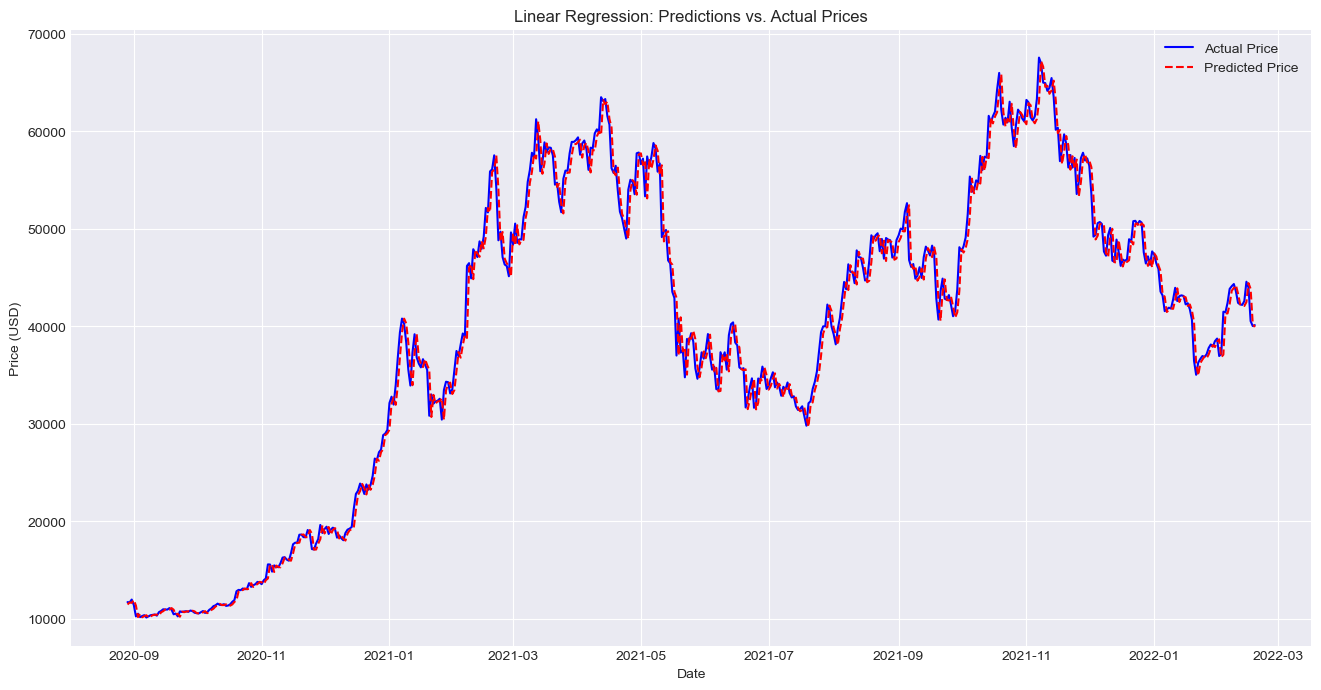


Predicted price for the next day after 2022-02-18: $39917.62


In [12]:
### 5) Model Evaluation and Prediction

# Identify the best model (excluding LSTM for now as its test set is different)
traditional_models = {k: v for k, v in models.items() if k != 'LSTM'}
best_model_name = min(traditional_models, key=traditional_models.get)
print(f"\nBest Traditional Model: {best_model_name}")

# Use the best model for final evaluation and prediction
if best_model_name == 'XGBoost':
    best_model = xgb
    final_preds = preds_xgb
elif best_model_name == 'Random Forest':
    best_model = rf
    final_preds = preds_rf
elif best_model_name == 'Linear Regression':
    best_model = lr
    final_preds = preds_lr
else:
    best_model = svr
    final_preds = preds_svr


#  Evaluate the Best Model 
mae = mean_absolute_error(y_test, final_preds)
mse = mean_squared_error(y_test, final_preds)
r2 = r2_score(y_test, final_preds)

print(f"\n--- {best_model_name} Final Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

#  Visualize Predictions vs. Actual Prices 
plt.figure(figsize=(16, 8))
plt.title(f'{best_model_name}: Predictions vs. Actual Prices')
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue')
plt.plot(y_test.index, final_preds, label='Predicted Price', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

#  Prediction on Future Data 
# To predict the next day's price, you would use the most recent data available.
# We'll use the last record from our dataset as a simulation.
last_data_point = X_test_scaled[-1].reshape(1, -1)
predicted_price = best_model.predict(last_data_point)

print(f"\nPredicted price for the next day after {y_test.index[-1].date()}: ${predicted_price[0]:.2f}")

#### Conclusion
## Model Performance: This project successfully demonstrates how to preprocess historical data, perform exploratory analysis, and train multiple machine learning models to predict Bitcoin prices. Typically, models like XGBoost and Random Forest perform well on tabular data due to their ability to capture complex non-linear relationships. The LSTM model is specifically designed for sequential data and often yields the best results, although it requires more data and computational resources.
## Trader Insights: The model provides traders with a predicted price for the next day, which, when combined with technical indicators and market sentiment, can help in making more informed trading decisions.